../data_raw/nasa_battery
../data_raw/nasa_battery\.ipynb_checkpoints
../data_raw/nasa_battery\cleaned_dataset
   metadata.csv
../data_raw/nasa_battery\cleaned_dataset\.ipynb_checkpoints
   metadata-checkpoint.csv
../data_raw/nasa_battery\cleaned_dataset\data
   00001.csv
   00002.csv
   00003.csv
   00004.csv
   00005.csv
   00006.csv
   00007.csv
   00008.csv
   00009.csv
   00010.csv
   00011.csv
   00012.csv
   00013.csv
   00014.csv
   00015.csv
   00016.csv
   00017.csv
   00018.csv
   00019.csv
   00020.csv
   00021.csv
   00022.csv
   00023.csv
   00024.csv
   00025.csv
   00026.csv
   00027.csv
   00028.csv
   00029.csv
   00030.csv
   00031.csv
   00032.csv
   00033.csv
   00034.csv
   00035.csv
   00036.csv
   00037.csv
   00038.csv
   00039.csv
   00040.csv
   00041.csv
   00042.csv
   00043.csv
   00044.csv
   00045.csv
   00046.csv
   00047.csv
   00048.csv
   00049.csv
   00050.csv
   00051.csv
   00052.csv
   00053.csv
   00054.csv
   00055.csv
   00056.csv
   00057.csv


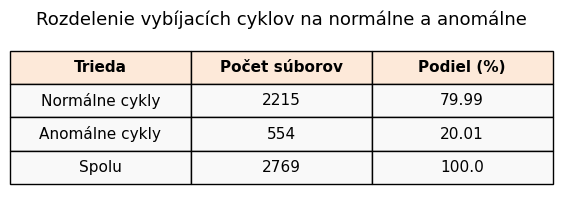

   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time source_file  Capacity  y_true_file  
0         0.000   0.000   00001.csv  1.674305            0  
1         4.262   9.360   00001.csv  1.674305            0  
2         3.465  23.281   00001.csv  1.674305            0  
3         3.451  36.406   00001.csv  1.674305            0  
4         3.438  49.625   00001.csv  1.674305            0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764674 entries, 0 to 764673
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ----

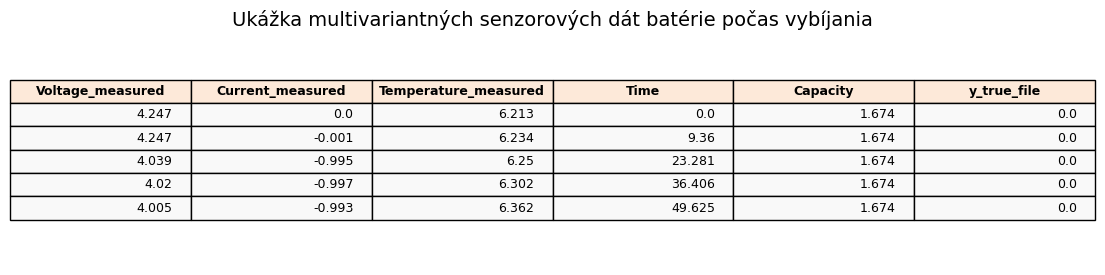

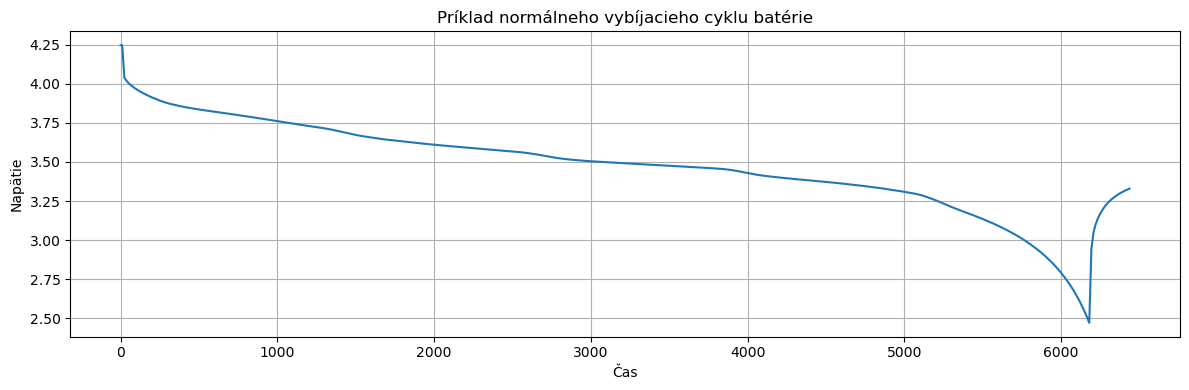

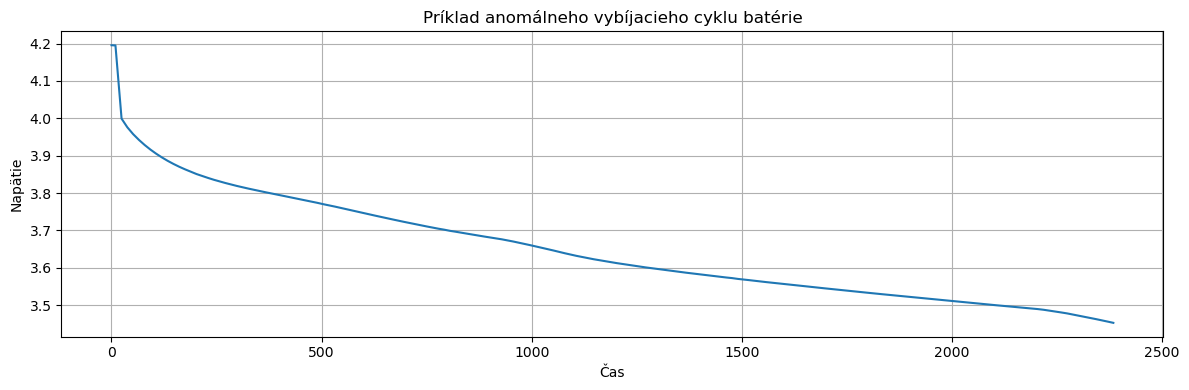

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

base = "../data_raw/nasa_battery"

for root, dirs, files in os.walk(base):
    print(root)
    for f in files:
        print("  ", f)

meta = pd.read_csv("../data_raw/nasa_battery/cleaned_dataset/metadata.csv")

print(meta.head())
print(meta.columns)

meta_dis = meta[meta["type"] == "discharge"].copy()
print(meta_dis.head())

meta_dis["Capacity"] = (
    meta_dis["Capacity"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.strip()
)
meta_dis["Capacity"] = pd.to_numeric(meta_dis["Capacity"], errors="coerce")

meta_dis = meta_dis.dropna(subset=["Capacity"]).reset_index(drop=True)

capacity_threshold = meta_dis["Capacity"].quantile(0.20)

meta_dis["y_true_file"] = (meta_dis["Capacity"] < capacity_threshold).astype(int)

print("Capacity threshold:", capacity_threshold)
print(meta_dis["y_true_file"].value_counts())

split_counts = meta_dis["y_true_file"].value_counts().sort_index()
normal_files = int(split_counts.get(0, 0))
anomaly_files = int(split_counts.get(1, 0))
total_files = normal_files + anomaly_files

split_df = pd.DataFrame({
    "Trieda": ["Normálne cykly", "Anomálne cykly", "Spolu"],
    "Počet súborov": [normal_files, anomaly_files, total_files],
    "Podiel (%)": [
        round(normal_files / total_files * 100, 2) if total_files > 0 else 0,
        round(anomaly_files / total_files * 100, 2) if total_files > 0 else 0,
        100.00
    ]
})

print("\nRozdelenie cyklov podľa Capacity:")
print(split_df)

split_df.to_csv("../data_processed/nasa_capacity_split_table.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis("off")

table = ax.table(
    cellText=split_df.values,
    colLabels=split_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#fde9d9")
    else:
        cell.set_facecolor("#f9f9f9")

plt.title("Rozdelenie vybíjacích cyklov na normálne a anomálne", fontsize=13)
fig.savefig("nasa_capacity_split_table.png", dpi=300, bbox_inches="tight")
plt.show()

base_data = "../data_raw/nasa_battery/cleaned_dataset/data"

dfs = []

for _, row in meta_dis.iterrows():
    fname = row["filename"]
    path = os.path.join(base_data, fname)

    if os.path.exists(path):
        df = pd.read_csv(path)
        df["source_file"] = fname
        df["Capacity"] = row["Capacity"]
        df["y_true_file"] = row["y_true_file"]
        dfs.append(df)

data_all = pd.concat(dfs, ignore_index=True)

print(data_all.head())
print(data_all.info())
print(data_all.describe())

num_cols = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Current_load",
    "Voltage_load",
    "Time"
]

features = data_all[num_cols].copy()
features["Capacity"] = data_all["Capacity"]
features["y_true_file"] = data_all["y_true_file"]
features["source_file"] = data_all["source_file"]

print(features.head())

scaler = StandardScaler()
X = scaler.fit_transform(features[num_cols])

features.to_csv("../data_processed/nasa_battery_features.csv", index=False)
joblib.dump(scaler, "../data_processed/nasa_battery_scaler.pkl")

print("Saved features + scaler")

window = 50

rolling_parts = []

for fname, group in data_all.groupby("source_file"):
    group = group.sort_values("Time").reset_index(drop=True)

    feat_part = pd.DataFrame({
        "source_file": group["source_file"],
        "Capacity": group["Capacity"],
        "y_true_file": group["y_true_file"],
        "Voltage_measured": group["Voltage_measured"],
        "Current_measured": group["Current_measured"],
        "Temperature_measured": group["Temperature_measured"],
        "Current_load": group["Current_load"],
        "Voltage_load": group["Voltage_load"],
        "Time": group["Time"],

        "V": group["Voltage_measured"],
        "I": group["Current_measured"],
        "T": group["Temperature_measured"],

        "V_diff1": group["Voltage_measured"].diff(),
        "I_diff1": group["Current_measured"].diff(),
        "T_diff1": group["Temperature_measured"].diff(),

        "V_roll_mean": group["Voltage_measured"].rolling(window).mean(),
        "V_roll_std": group["Voltage_measured"].rolling(window).std(),
        "V_roll_min": group["Voltage_measured"].rolling(window).min(),
        "V_roll_max": group["Voltage_measured"].rolling(window).max(),

        "T_roll_mean": group["Temperature_measured"].rolling(window).mean(),
        "T_roll_std": group["Temperature_measured"].rolling(window).std(),

        "I_roll_mean": group["Current_measured"].rolling(window).mean(),
        "I_roll_std": group["Current_measured"].rolling(window).std(),
    })

    feat_part = feat_part.dropna().reset_index(drop=True)
    rolling_parts.append(feat_part)

feat = pd.concat(rolling_parts, ignore_index=True)

print(feat.head())

feat.to_csv("../data_processed/nasa_battery_features_rolling.csv", index=False)
print("Saved rolling features")

df_nasa = pd.read_csv("../data_processed/nasa_battery_features.csv")

print(df_nasa.columns)

df_show = df_nasa[[
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Time",
    "Capacity",
    "y_true_file"
]].copy()

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=df_show.head().round(3).values,
    colLabels=df_show.columns,
    loc='center'
)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#fde9d9')
    else:
        cell.set_facecolor('#f9f9f9')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

plt.title("Ukážka multivariantných senzorových dát batérie počas vybíjania", fontsize=14)

fig.savefig("nasa_table.png", dpi=300, bbox_inches='tight')
plt.show()

normal_file = meta_dis[meta_dis["y_true_file"] == 0]["filename"].iloc[0]
anomaly_file = meta_dis[meta_dis["y_true_file"] == 1]["filename"].iloc[0]

plot_normal = data_all[data_all["source_file"] == normal_file].copy()
plot_anomaly = data_all[data_all["source_file"] == anomaly_file].copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_normal["Time"].values, plot_normal["Voltage_measured"].values)
plt.title("Príklad normálneho vybíjacieho cyklu batérie")
plt.xlabel("Čas")
plt.ylabel("Napätie")
plt.grid(True)
plt.tight_layout()
plt.savefig("nasa_normal_cycle.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(plot_anomaly["Time"].values, plot_anomaly["Voltage_measured"].values)
plt.title("Príklad anomálneho vybíjacieho cyklu batérie")
plt.xlabel("Čas")
plt.ylabel("Napätie")
plt.grid(True)
plt.tight_layout()
plt.savefig("nasa_anomaly_cycle.png", dpi=300, bbox_inches="tight")
plt.show()